## **Data Cleaning**

### Import Liblary

In [17]:
# Import liblary
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [18]:
# Load Dataset
df = pd.read_csv('/content/credit_risk_raw.csv')

In [19]:
# Menampilkan 5 data teratas
df.head(5)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Initial Inspection

In [20]:
df.shape

(9692, 122)

In [22]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

In [23]:
selected_columns = [
    'SK_ID_CURR',
    'TARGET',
    'CODE_GENDER',
    'CNT_CHILDREN',
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'DAYS_EMPLOYED',
    'DAYS_BIRTH',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_INCOME_TYPE',
    'OCCUPATION_TYPE',
    'CNT_FAM_MEMBERS',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'NAME_HOUSING_TYPE',
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3',
    'REGION_RATING_CLIENT',
    'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_QRT',
    'AMT_REQ_CREDIT_BUREAU_YEAR'
]

df = df[selected_columns]

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9692 entries, 0 to 9691
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   SK_ID_CURR                  9692 non-null   int64  
 1   TARGET                      9692 non-null   int64  
 2   CODE_GENDER                 9692 non-null   object 
 3   CNT_CHILDREN                9692 non-null   int64  
 4   AMT_INCOME_TOTAL            9692 non-null   float64
 5   AMT_CREDIT                  9692 non-null   float64
 6   AMT_ANNUITY                 9692 non-null   float64
 7   AMT_GOODS_PRICE             9685 non-null   float64
 8   DAYS_EMPLOYED               9691 non-null   float64
 9   DAYS_BIRTH                  9691 non-null   float64
 10  NAME_EDUCATION_TYPE         9692 non-null   object 
 11  NAME_FAMILY_STATUS          9692 non-null   object 
 12  NAME_INCOME_TYPE            9692 non-null   object 
 13  OCCUPATION_TYPE             6696 

In [25]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_EMPLOYED,DAYS_BIRTH,CNT_FAM_MEMBERS,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,REGION_RATING_CLIENT,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,9692.000000,9692.000000,9692.000000,9.692000e+03,9.692000e+03,9692.000000,9.685000e+03,9691.000000,9691.000000,9691.000000,4230.000000,9665.000000,7766.000000,9691.000000,8376.000000,8376.000000,8376.000000
mean,105652.346574,0.077899,0.415600,1.676262e+05,6.013997e+05,27100.230396,5.410311e+05,62808.813435,-16029.072129,2.156124,0.504916,0.515932,0.512167,2.045403,0.276624,0.268983,1.888968
std,3256.587947,0.268027,0.718289,9.466657e+04,4.040238e+05,14419.822666,3.714979e+05,140461.490262,4342.680723,0.903427,0.209746,0.189329,0.196214,0.510370,0.932214,0.614159,1.862072
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,2596.500000,4.500000e+04,-15632.000000,-25160.000000,1.000000,0.024417,0.000074,0.000527,1.000000,0.000000,0.000000,0.000000
25%,102827.750000,0.000000,0.000000,1.125000e+05,2.700000e+05,16434.000000,2.385000e+05,-2822.500000,-19605.000000,2.000000,0.334934,0.394033,0.374021,2.000000,0.000000,0.000000,0.000000
50%,105665.500000,0.000000,0.000000,1.440000e+05,5.123925e+05,24970.500000,4.500000e+05,-1229.000000,-15782.000000,2.000000,0.512363,0.566171,0.535276,2.000000,0.000000,0.000000,1.000000
75%,108462.250000,0.000000,1.000000,2.025000e+05,8.100000e+05,34671.375000,6.840000e+05,-293.000000,-12401.000000,3.000000,0.674778,0.664661,0.670652,2.000000,0.000000,0.000000,3.000000
max,111275.000000,1.000000,7.000000,1.935000e+06,2.961000e+06,135936.000000,2.961000e+06,365243.000000,-7705.000000,9.000000,0.929394,0.855000,0.885488,3.000000,16.000000,8.000000,13.000000


In [26]:
df.isnull().sum()

,0
SK_ID_CURR,0
TARGET,0
CODE_GENDER,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
AMT_CREDIT,0
AMT_ANNUITY,0
AMT_GOODS_PRICE,7
DAYS_EMPLOYED,1
DAYS_BIRTH,1


### Menangani Missing Values

In [27]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage.sort_values(ascending=False)

,0
EXT_SOURCE_1,56.355757
OCCUPATION_TYPE,30.912092
EXT_SOURCE_3,19.872059
AMT_REQ_CREDIT_BUREAU_QRT,13.578209
AMT_REQ_CREDIT_BUREAU_MON,13.578209
AMT_REQ_CREDIT_BUREAU_YEAR,13.578209
EXT_SOURCE_2,0.278580
AMT_GOODS_PRICE,0.072225
DAYS_EMPLOYED,0.010318
REGION_RATING_CLIENT,0.010318


In [36]:
# Menangani missing <5 %
cols_small_missing = [
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'CNT_FAM_MEMBERS',
    'REGION_RATING_CLIENT',
    'DAYS_EMPLOYED',
    'AMT_GOODS_PRICE',
    'EXT_SOURCE_2'
]

for col in cols_small_missing:
    df[col] = df[col].fillna(df[col].median())

In [31]:
# Menangi missing >5% and <20%
cols = [
    'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_QRT',
    'AMT_REQ_CREDIT_BUREAU_YEAR'
]

df[cols] = df[cols].fillna(0)


In [32]:
df['EXT_SOURCE_3'].fillna(
    df['EXT_SOURCE_3'].median(),
    inplace=True
)

/tmp/ipykernel_691/2486280612.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['EXT_SOURCE_3'].fillna(


In [33]:
df['OCCUPATION_TYPE'].fillna(
    'Unknown',
    inplace=True
)

/tmp/ipykernel_691/3735236140.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['OCCUPATION_TYPE'].fillna(


In [34]:
# Missing > 50%
df.drop(columns=['EXT_SOURCE_1'], inplace=True)

In [37]:
df.isnull().sum()

,0
SK_ID_CURR,0
TARGET,0
CODE_GENDER,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
AMT_CREDIT,0
AMT_ANNUITY,0
AMT_GOODS_PRICE,0
DAYS_EMPLOYED,0
DAYS_BIRTH,0


In [38]:
df.duplicated().sum()

np.int64(0)

### Outlier Chek

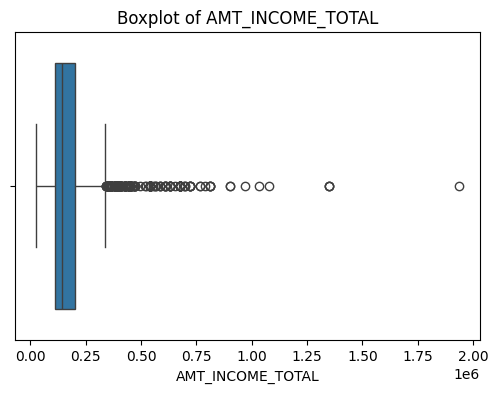

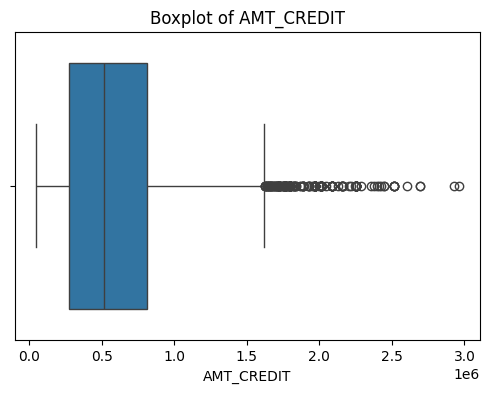

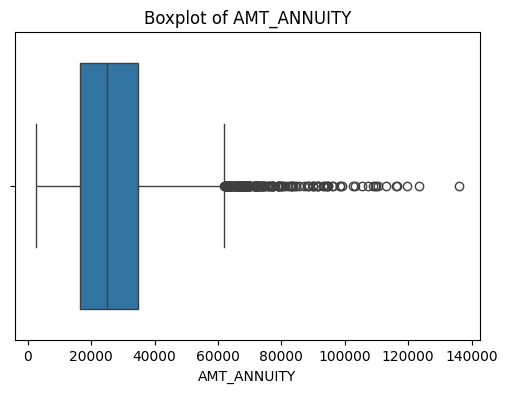

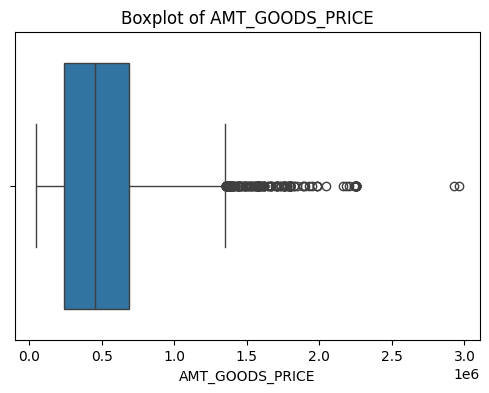

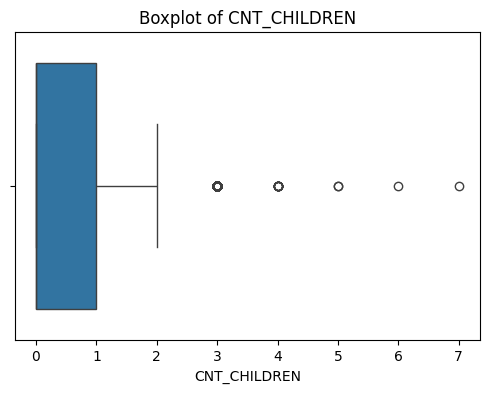

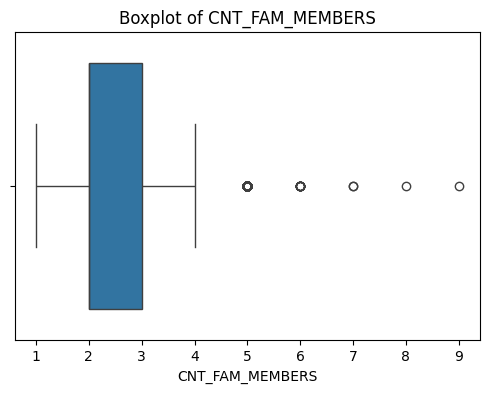

In [40]:
outlier_cols = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'CNT_CHILDREN',
    'CNT_FAM_MEMBERS'
]

for col in outlier_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

### Save Dataset

In [42]:
df.to_csv(
    'cleaned_data.csv',
    index=False
)